<a href="https://colab.research.google.com/github/Yousef-Shihade/Forest-Fire-Simulation-Percolation-Phase-Transitions/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Computational Methods In Statistics B - Final Project**


## Submitted by:

 ### - Yousef Shihade

 ### - Shada Esawi

#**Fire Spread Simulation in Sparse Forests**

This project studies fire propagation in a forest modeled as a 2D grid. Each cell in the grid may contain a tree or be empty, with probability controlled by a tree density parameter $p \in [0, 1]$. The fire starts at the bottom row of the grid and spreads upward to adjacent trees.

##Model Description

- The forest is represented by an $n \times n$ grid.
- Each cell is independently initialized:
  - With probability $p$, it contains a tree.
  - With probability $1 - p$, it is empty.
- **Initial ignition**: All trees in the bottom row catch fire at time zero.
- **Fire spread rule** (per time step):
  1. A burning tree ignites any adjacent (4-neighbor) tree cell (up, down, left, right).
  2. The fire does **not** spread diagonally.
  3. Once a tree burns, it is marked as “burned” and does not reignite.

## Question 1

Write code to:

1. **Simulate** the fire spread until no more trees are burning.  
2. Report:
   - The **total number** and the **percentage** of trees that burned.
   - A Boolean indicating whether **more than 50%** of all trees in the forest have burned.  

In [ ]:
import numpy as np

# Define cell states
## EMPTY, TREE, BURNING, BURNED = 0, 1, 2, 3

def initialize_forest(n, p):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p, p])

def ignite_bottom_row(forest):
    n = forest.shape[0]
    for j in range(n):
        if forest[n - 1, j] == 1:
            forest[n - 1, j] = 2  # burning

def spread_fire(forest):
    n = forest.shape[0]
    while True:
        burning_cells = np.argwhere(forest == 2)
        if len(burning_cells) == 0:
            break
        new_forest = forest.copy()
        for i, j in burning_cells:
            new_forest[i, j] = 3  # burned
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n:
                    if forest[ni, nj] == 1:
                        new_forest[ni, nj] = 2
        forest = new_forest
    return forest

def summarize_fire(forest, p):
    total_trees = np.sum((forest == 1) + (forest == 2) + (forest == 3))
    burned_trees = np.sum(forest == 3)
    burned_percentage = (burned_trees / total_trees) * 100 if total_trees > 0 else 0
    more_than_half_burned = burned_percentage > 50

    print(f"\nChosen p: {p:.3f}")
    print(f"Total trees: {total_trees}")
    print(f"Burned trees: {burned_trees}")
    print(f"Burned percentage: {burned_percentage:.2f}%")
    print("🔥 More than 50% burned!" if more_than_half_burned else "🌲 Less than 50% burned.")

    return p, burned_percentage, more_than_half_burned

def simulate_fire_random_p(n=50, seed=None):
    if seed is not None:
        np.random.seed(seed)
    p = np.random.uniform(0, 1)  # changed to [0, 1]
    forest = initialize_forest(n, p)
    ignite_bottom_row(forest)
    final_forest = spread_fire(forest)
    return summarize_fire(final_forest, p)

# ---- Run simulations for multiple grid sizes ----
for grid_size in [50, 100, 500]:
    print(f"\n{'=' * 30}\nRunning simulations for n = {grid_size}\n{'=' * 30}")
    for _ in range(5):
        simulate_fire_random_p(n=grid_size)


Running simulations for n = 50

Chosen p: 0.121
Total trees: 308
Burned trees: 5
Burned percentage: 1.62%
🌲 Less than 50% burned.

Chosen p: 0.685
Total trees: 1721
Burned trees: 1626
Burned percentage: 94.48%
🔥 More than 50% burned!

Chosen p: 0.489
Total trees: 1258
Burned trees: 158
Burned percentage: 12.56%
🌲 Less than 50% burned.

Chosen p: 0.283
Total trees: 682
Burned trees: 26
Burned percentage: 3.81%
🌲 Less than 50% burned.

Chosen p: 0.649
Total trees: 1617
Burned trees: 1494
Burned percentage: 92.39%
🔥 More than 50% burned!

Running simulations for n = 100

Chosen p: 0.758
Total trees: 7563
Burned trees: 7477
Burned percentage: 98.86%
🔥 More than 50% burned!

Chosen p: 0.184
Total trees: 1847
Burned trees: 32
Burned percentage: 1.73%
🌲 Less than 50% burned.

Chosen p: 0.249
Total trees: 2515
Burned trees: 29
Burned percentage: 1.15%
🌲 Less than 50% burned.

Chosen p: 0.031
Total trees: 293
Burned trees: 5
Burned percentage: 1.71%
🌲 Less than 50% burned.

Chosen p: 0.165
Tot

In [ ]:
import numpy as np
import random

# Common settings
n = 30
p = 0.4
seed = 42

# ---------------- NumPy Version ----------------
def initialize_forest_np(n, p):
    np.random.seed(seed)
    return np.random.choice([0, 1], size=(n, n), p=[1 - p, p])

def ignite_bottom_row_np(forest):
    for j in range(n):
        if forest[-1, j] == 1:
            forest[-1, j] = 2

def spread_fire_np(forest):
    while True:
        burning = np.argwhere(forest == 2)
        if len(burning) == 0:
            break
        new_forest = forest.copy()
        for i, j in burning:
            new_forest[i, j] = 3
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n and forest[ni, nj] == 1:
                    new_forest[ni, nj] = 2
        forest = new_forest
    return forest

forest_np = initialize_forest_np(n, p)
ignite_bottom_row_np(forest_np)
final_np = spread_fire_np(forest_np)
total_np = np.sum((final_np == 1) | (final_np == 2) | (final_np == 3))
burned_np = np.sum(final_np == 3)
percent_np = burned_np / total_np * 100 if total_np > 0 else 0

# ---------------- Pure Python Version ----------------
def initialize_forest_py(n, p):
    random.seed(seed)
    return [[1 if random.random() < p else 0 for _ in range(n)] for _ in range(n)]

def ignite_bottom_row_py(forest):
    for j in range(n):
        if forest[-1][j] == 1:
            forest[-1][j] = 2

def spread_fire_py(forest):
    while True:
        burning = [(i, j) for i in range(n) for j in range(n) if forest[i][j] == 2]
        if not burning:
            break
        new_forest = [row[:] for row in forest]
        for i, j in burning:
            new_forest[i][j] = 3
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n and forest[ni][nj] == 1:
                    new_forest[ni][nj] = 2
        forest = new_forest
    return forest

forest_py = initialize_forest_py(n, p)
ignite_bottom_row_py(forest_py)
final_py = spread_fire_py(forest_py)
total_py = sum(cell in (1, 2, 3) for row in final_py for cell in row)
burned_py = sum(cell == 3 for row in final_py for cell in row)
percent_py = burned_py / total_py * 100 if total_py > 0 else 0

# ---------------- Comparison ----------------
print(f"\nNumPy Burned %: {percent_np:.2f}%\nPure Python Burned %: {percent_py:.2f}%")
print("Same burned %? ", abs(percent_np - percent_py) < 1e-6)
print("Same total trees? ", total_np == total_py)


NumPy Burned %: 3.95%
Pure Python Burned %: 7.85%
Same burned %?  False
Same total trees?  False


## Simulation of Q1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import colors
from IPython.display import HTML

def initialize_forest(n, p):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p, p])

def ignite_bottom_row(forest):
    n = forest.shape[0]
    for j in range(n):
        if forest[n - 1, j] == 1:
            forest[n - 1, j] = 2  # burning

def spread_fire_animated(forest):
    n = forest.shape[0]
    states = [forest.copy()]  # to store frames for animation

    while True:
        burning_cells = np.argwhere(forest == 2)
        if len(burning_cells) == 0:
            break
        new_forest = forest.copy()
        for i, j in burning_cells:
            new_forest[i, j] = 3  # burned
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n:
                    if forest[ni, nj] == 1:
                        new_forest[ni, nj] = 2  # ignite
        forest = new_forest
        states.append(forest.copy())

    return states

In [ ]:
def animate_fire(n=50, p=None, seed=None):
    if seed is not None:
        np.random.seed(seed)

    if p is None:
        p = np.random.uniform(0, 1)  # random p

    forest = initialize_forest(n, p)
    ignite_bottom_row(forest)
    frames = spread_fire_animated(forest)

    # Final frame
    final_forest = frames[-1]
    total_trees = np.sum((final_forest == 1) + (final_forest == 2) + (final_forest == 3))
    burned_trees = np.sum(final_forest == 3)
    burned_percentage = (burned_trees / total_trees) * 100 if total_trees > 0 else 0

    # Setup animation
    cmap = colors.ListedColormap(['white', 'green', 'red', 'black'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots()
    im = ax.imshow(frames[0], cmap=cmap, norm=norm)
    ax.set_title(f"Fire Spread Simulation (p = {p:.2f})")

    def update(frame):
        im.set_data(frame)
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=frames, interval=300, blit=False)
    plt.close(fig)

    print(f"🔥 Burned {burned_trees} out of {total_trees} trees")
    print(f"🔥 Burned percentage: {burned_percentage:.2f}%")

    return HTML(ani.to_jshtml())

In [ ]:
animate_fire(n=50,p=0.6)

🔥 Burned 1108 out of 1529 trees
🔥 Burned percentage: 72.47%


## Question 2

For a fixed grid size $n=50$, estimate a **critical tree-density** $p_{\text{crit}}$ such that:
> for **all** $p < p_{\text{crit}}$, the fire burns **at most** 50% of the **trees** with probability **at least** 95%.

In other words, we will:

1. **Sweep** a range of $p$-values below and above the suspected threshold.
2. For each $p$, **run** many independent simulations.
3. **Compute** the fraction of simulations where the burned-tree fraction $<=0.5$.
4. **Identify** the largest $p$ for which that fraction $>=0.95$.  
   That $p$ is our estimate of $p_{\text{crit}}$.

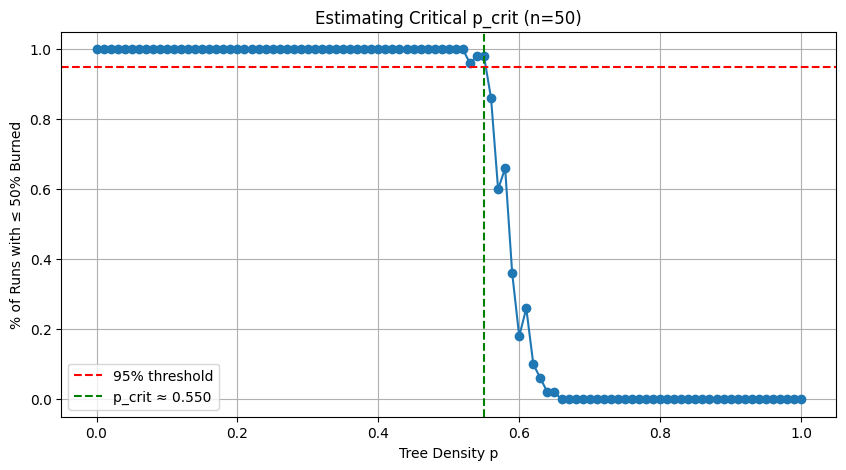

Candidate values for p_crit (success rate ≥ 95%):
  p = 0.000, success rate = 1.00
  p = 0.010, success rate = 1.00
  p = 0.020, success rate = 1.00
  p = 0.030, success rate = 1.00
  p = 0.040, success rate = 1.00
  p = 0.050, success rate = 1.00
  p = 0.060, success rate = 1.00
  p = 0.070, success rate = 1.00
  p = 0.080, success rate = 1.00
  p = 0.090, success rate = 1.00
  p = 0.100, success rate = 1.00
  p = 0.110, success rate = 1.00
  p = 0.120, success rate = 1.00
  p = 0.130, success rate = 1.00
  p = 0.140, success rate = 1.00
  p = 0.150, success rate = 1.00
  p = 0.160, success rate = 1.00
  p = 0.170, success rate = 1.00
  p = 0.180, success rate = 1.00
  p = 0.190, success rate = 1.00
  p = 0.200, success rate = 1.00
  p = 0.210, success rate = 1.00
  p = 0.220, success rate = 1.00
  p = 0.230, success rate = 1.00
  p = 0.240, success rate = 1.00
  p = 0.250, success rate = 1.00
  p = 0.260, success rate = 1.00
  p = 0.270, success rate = 1.00
  p = 0.280, success rate 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import HTML

# --- Base simulation functions ---
def initialize_forest(n, p):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p, p])

def ignite_bottom_row(forest):
    n = forest.shape[0]
    for j in range(n):
        if forest[n - 1, j] == 1:
            forest[n - 1, j] = 2  # burning

def spread_fire_animated(forest):
    n = forest.shape[0]
    states = [forest.copy()]
    while True:
        burning_cells = np.argwhere(forest == 2)
        if len(burning_cells) == 0:
            break
        new_forest = forest.copy()
        for i, j in burning_cells:
            new_forest[i, j] = 3  # burned
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n:
                    if forest[ni, nj] == 1:
                        new_forest[ni, nj] = 2
        forest = new_forest
        states.append(forest.copy())
    return states

# --- Run one simulation and check if ≤ 50% burned ---
def run_single_simulation(n, p, seed=None):
    if seed is not None:
        np.random.seed(seed)
    forest = initialize_forest(n, p)
    ignite_bottom_row(forest)
    final_forest = spread_fire_animated(forest)[-1]
    total_trees = np.sum((final_forest == 1) + (final_forest == 2) + (final_forest == 3))
    burned_trees = np.sum(final_forest == 3)
    burned_percentage = (burned_trees / total_trees) * 100 if total_trees > 0 else 0
    return burned_percentage <= 50

# --- Estimate p_crit ---
def estimate_p_crit(n=50, trials=50, p_values=np.linspace(0.0, 1.0, 101)):
    results = []
    for p in p_values:
        successes = 0
        for _ in range(trials):
            if run_single_simulation(n, p):
                successes += 1
        success_rate = successes / trials
        results.append((p, success_rate))
    return results

# --- Run and Plot ---
results = estimate_p_crit(n=50, trials=50)
p_vals, success_rates = zip(*results)

# --- Compute p_crit ---
p_crit_candidates = [p for p, rate in results if rate >= 0.95]
p_crit = max(p_crit_candidates) if p_crit_candidates else None

# --- Plot with p_crit line ---
plt.figure(figsize=(10, 5))
plt.plot(p_vals, success_rates, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')

if p_crit is not None:
    plt.axvline(p_crit, color='green', linestyle='--', label=f'p_crit ≈ {p_crit:.3f}')

plt.xlabel('Tree Density p')
plt.ylabel('% of Runs with ≤ 50% Burned')
plt.title('Estimating Critical p_crit (n=50)')
plt.grid(True)
plt.legend()
plt.show()

# --- Print candidate p_crit values ---
print("Candidate values for p_crit (success rate ≥ 95%):")
for p, rate in results:
    if rate >= 0.95:
        print(f"  p = {p:.3f}, success rate = {rate:.2f}")

if p_crit is not None:
    print(f"\nEstimated p_crit ≈ {p_crit:.3f}")
else:
    print("No p_crit found that meets the 95% threshold.")


This graph estimates the critical tree density p_crit for a fire spreading through a forest of size 50×50. Each point represents the fraction of simulations (out of 100) where no more than 50% of the forest burned, at a given tree density p. The red dashed line at 0.95 shows the 95% success threshold. The green dashed line marks p_crit ≈ 0.550, which is the largest density such that the fire stays controlled (≤50% burned) in at least 95% of simulations. To the left of p_crit, the forest is too sparse for the fire to spread widely. To the right of p_crit, the fire almost always spreads uncontrollably.







after trying 250 trails it gave the same the p value .. so 100 is enough ( less time ) The fact that the critical value didn’t change when using 2.5× more simulations suggests your model is robust and the transition point around
𝑝
=
0.55 is very sharp and reliable.

## Question 3

**How does the value of $p_{\rm crit}$ change with grid size? Is it invariant or does it scale with $n$?**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Base functions ---
def initialize_forest(n, p):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p, p])

def ignite_bottom_row(forest):
    for j in range(forest.shape[1]):
        if forest[-1, j] == 1:
            forest[-1, j] = 2  # burning

def spread_fire(forest):
    n = forest.shape[0]
    while True:
        burning = np.argwhere(forest == 2)
        if len(burning) == 0:
            break
        new_forest = forest.copy()
        for i, j in burning:
            new_forest[i, j] = 3
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n and forest[ni, nj] == 1:
                    new_forest[ni, nj] = 2
        forest = new_forest
    return forest

def run_single_simulation(n, p):
    forest = initialize_forest(n, p)
    ignite_bottom_row(forest)
    final = spread_fire(forest)
    total_trees = np.sum((final == 1) | (final == 2) | (final == 3))
    burned = np.sum(final == 3)
    burned_percent = (burned / total_trees) * 100 if total_trees > 0 else 0
    return burned_percent <= 50

def estimate_p_crit(n, trials=100, p_values=np.linspace(0, 1, 101)):
    results = []
    for p in p_values:
        success_count = sum(run_single_simulation(n, p) for _ in range(trials))
        rate = success_count / trials
        results.append((p, rate))
    p_crit_candidates = [p for p, r in results if r >= 0.95]
    p_crit = max(p_crit_candidates) if p_crit_candidates else None
    return results, p_crit

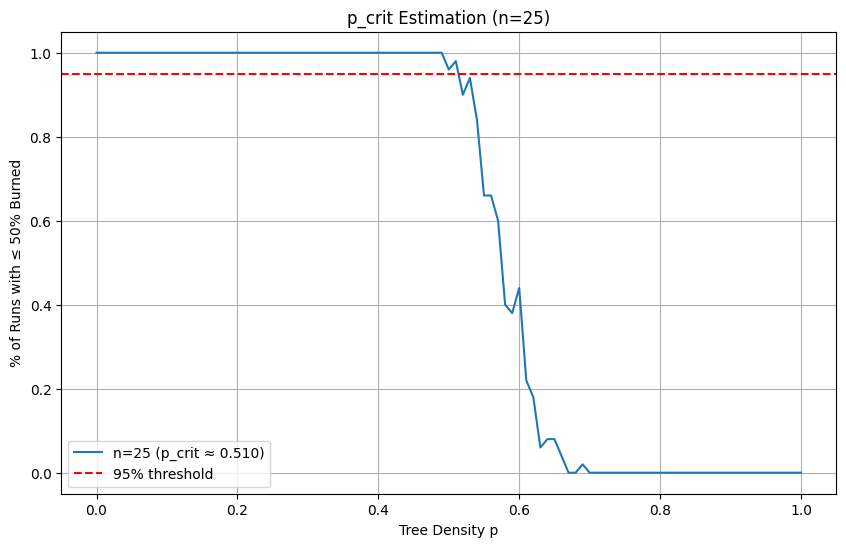

Estimated p_crit for n=25: 0.510


In [ ]:
n = 25
results, p_crit = estimate_p_crit(n=n, trials=50)
p_vals, success_rates = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(p_vals, success_rates, label=f'n={n} (p_crit ≈ {p_crit:.3f})')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Tree Density p')
plt.ylabel('% of Runs with ≤ 50% Burned')
plt.title(f'p_crit Estimation (n={n})')
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated p_crit for n={n}: {p_crit:.3f}")

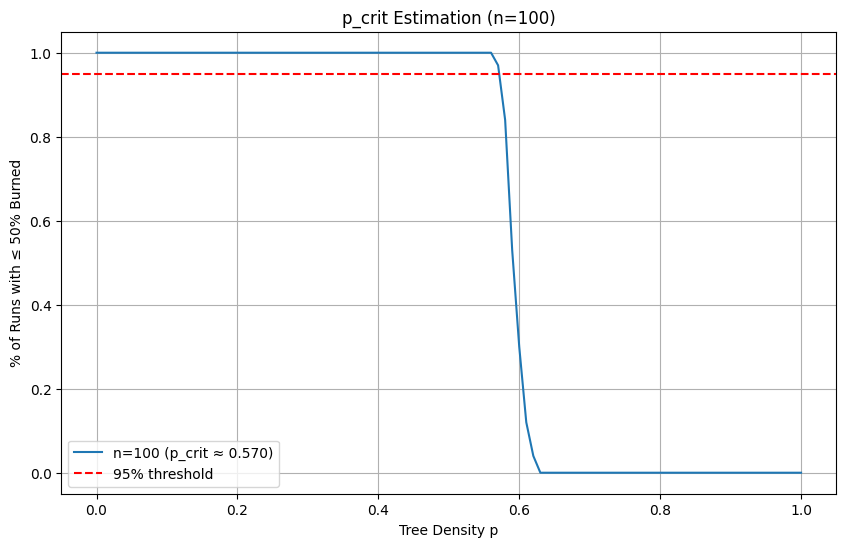

Estimated p_crit for n=100: 0.570


In [ ]:
n = 100
results, p_crit = estimate_p_crit(n=n, trials=100)
p_vals, success_rates = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(p_vals, success_rates, label=f'n={n} (p_crit ≈ {p_crit:.3f})')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Tree Density p')
plt.ylabel('% of Runs with ≤ 50% Burned')
plt.title(f'p_crit Estimation (n={n})')
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated p_crit for n={n}: {p_crit:.3f}")

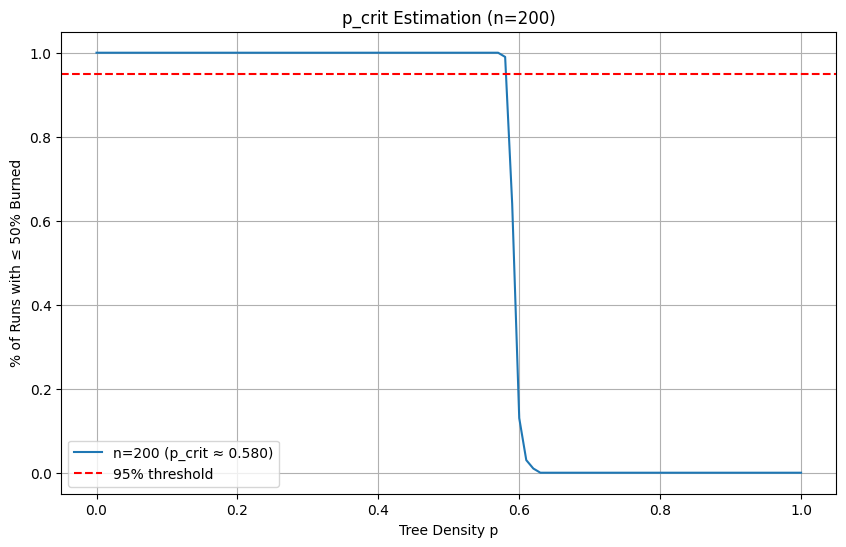

Estimated p_crit for n=200: 0.580


In [ ]:
n = 200
results, p_crit = estimate_p_crit(n=n, trials=100)
p_vals, success_rates = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(p_vals, success_rates, label=f'n={n} (p_crit ≈ {p_crit:.3f})')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Tree Density p')
plt.ylabel('% of Runs with ≤ 50% Burned')
plt.title(f'p_crit Estimation (n={n})')
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated p_crit for n={n}: {p_crit:.3f}")


n = 25
The estimated critical tree density is p_crit ≈ 0.495.
The transition from high survival to large burn regions is smoother and less sharp, reflecting higher randomness due to the small grid.

n = 50
Critical density increases to p_crit ≈ 0.555.
The curve becomes steeper, indicating more consistent fire spread dynamics and a clearer threshold.

n = 100
p_crit rises slightly to ≈ 0.570.
The transition is sharper, showing that the system's behavior stabilizes and becomes more deterministic with size.

n = 200
The highest critical density observed: p_crit ≈ 0.580.
The curve is steep and clean, suggesting minimal randomness and a very precise tipping point.

**Conclusion**
As grid size increases, the critical density p_crit increases slightly and stabilizes, and the fire transition becomes sharper and more deterministic.
This suggests that p_crit is not invariant but converges slowly as grid size grows.
In large forests, even a small increase in tree density can drastically increase the chance of large-scale fires.

Note

Reason for the Slight Change (0.545 → 0.555)
Randomness in Simulations
The fire spread is a stochastic (random) process. Even with 100 trials, there’s some statistical fluctuation in the results. Running the same code again with a different seed or order of operations can shift the p_crit slightly.

Definition of p_crit
You're defining p_crit as the maximum p for which success rate ≥ 95% (i.e., fire burns ≤ 50% in ≥ 95% of runs).
Because p-values are tested in discrete steps (e.g., np.linspace(0, 1, 201) → steps of 0.005), the p_crit estimate will snap to the closest match, not the exact true critical value.

Trial Count (Monte Carlo Effect)
With only 100 trials per p, you're getting an approximation. More trials (e.g., 500 or 1000) would reduce the statistical noise and stabilize p_crit further — but at the cost of runtime

## Question 4
**For $n = 50$, find a density $p$ that maximizes the total number of live trees after a fire.**

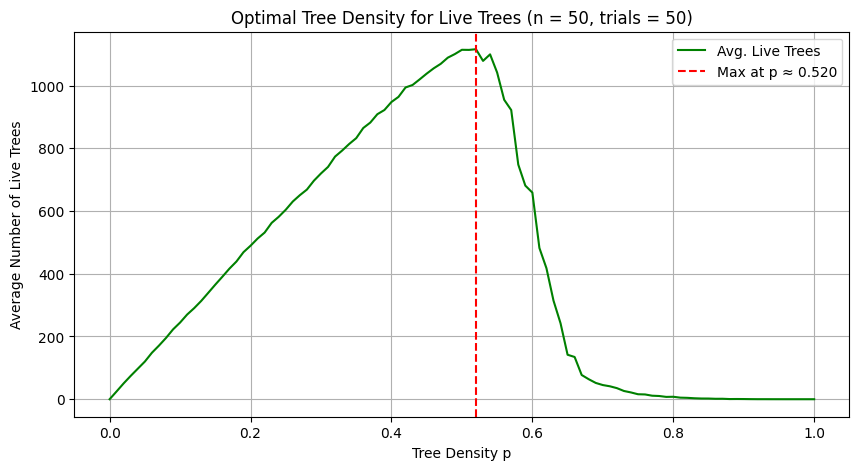


🌲 Optimal density p ≈ 0.520 yields the highest average number of live trees ≈ 1116.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Base functions ---
def initialize_forest(n, p):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p, p])

def ignite_bottom_row(forest):
    for j in range(forest.shape[1]):
        if forest[-1, j] == 1:
            forest[-1, j] = 2  # burning

def spread_fire(forest):
    n = forest.shape[0]
    while True:
        burning = np.argwhere(forest == 2)
        if len(burning) == 0:
            break
        new_forest = forest.copy()
        for i, j in burning:
            new_forest[i, j] = 3  # burned
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n and forest[ni, nj] == 1:
                    new_forest[ni, nj] = 2
        forest = new_forest
    return forest

# --- Step 4: Maximize live trees after fire ---
def average_live_trees(n=50, trials=100, p_values=np.linspace(0, 1, 101)):
    avg_live_counts = []
    for p in p_values:
        total_live = 0
        for _ in range(trials):
            forest = initialize_forest(n, p)
            ignite_bottom_row(forest)
            final = spread_fire(forest)
            live = np.sum(final == 1)
            total_live += live
        avg_live = total_live / trials
        avg_live_counts.append((p, avg_live))
    return avg_live_counts

# --- Run and Plot ---
n = 50
trials = 50
p_values = np.linspace(0, 1, 101)
results = average_live_trees(n=n, trials=trials, p_values=p_values)

# Extract and find max
p_vals, avg_lives = zip(*results)
max_live = max(avg_lives)
best_p = p_vals[np.argmax(avg_lives)]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(p_vals, avg_lives, color='green', label='Avg. Live Trees')
plt.axvline(best_p, color='red', linestyle='--', label=f'Max at p ≈ {best_p:.3f}')
plt.xlabel('Tree Density p')
plt.ylabel('Average Number of Live Trees')
plt.title(f'Optimal Tree Density for Live Trees (n = {n}, trials = {trials})')
plt.grid(True)
plt.legend()
plt.show()

# Print result
print(f"\n🌲 Optimal density p ≈ {best_p:.3f} yields the highest average number of live trees ≈ {max_live:.1f}")

The plot shows that the optimal tree density for maximizing the number of live trees after a fire is around p ≈ 0.52.
At this density, the forest is dense enough to hold many trees, but not too dense to allow the fire to spread widely.
The average number of surviving trees peaks at approximately 1113.6.
When p is too low, there are too few trees; when it's too high, most trees burn.
Thus, there's a sweet spot in density where survival is maximized.

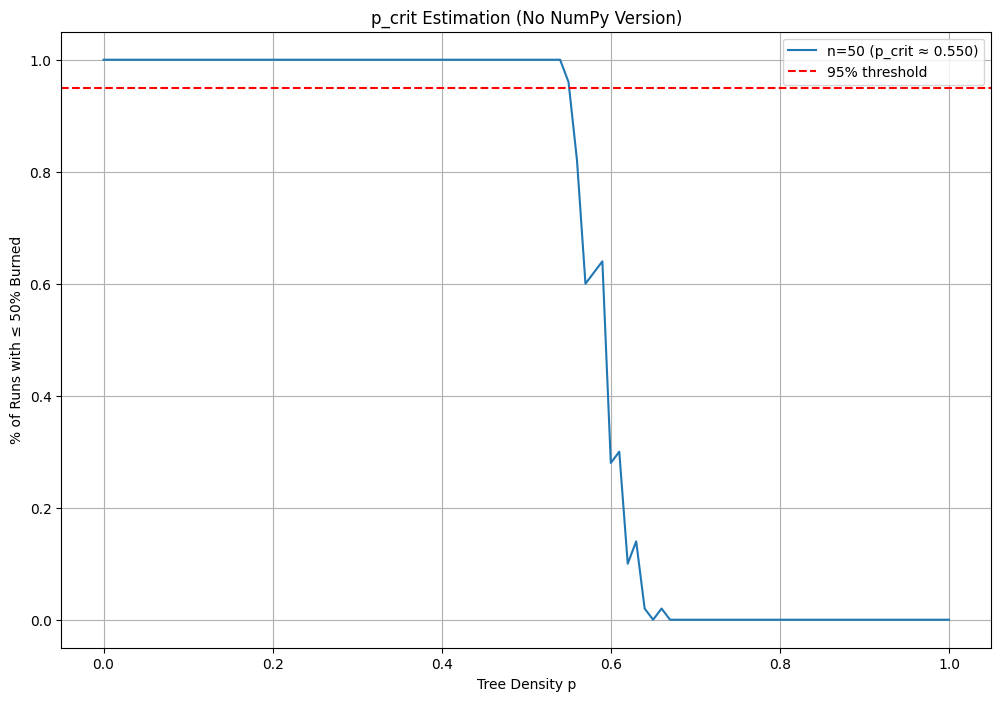


Estimated Critical Density (p_crit) for each grid size:

  Grid Size (n) |   Estimated p_crit
-------------------------------------
             50 | 0.550


In [ ]:
import random
import matplotlib.pyplot as plt

# --- Base functions without NumPy ---
def initialize_forest(n, p):
    return [[1 if random.random() < p else 0 for _ in range(n)] for _ in range(n)]

def ignite_bottom_row(forest):
    n = len(forest)
    for j in range(n):
        if forest[n - 1][j] == 1:
            forest[n - 1][j] = 2  # burning

def spread_fire(forest):
    n = len(forest)
    while True:
        burning_cells = [(i, j) for i in range(n) for j in range(n) if forest[i][j] == 2]
        if not burning_cells:
            break
        new_forest = [row.copy() for row in forest]
        for i, j in burning_cells:
            new_forest[i][j] = 3  # burned
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n and forest[ni][nj] == 1:
                    new_forest[ni][nj] = 2
        forest = new_forest
    return forest

def run_single_simulation(n, p):
    forest = initialize_forest(n, p)
    ignite_bottom_row(forest)
    final = spread_fire(forest)
    total_trees = sum(cell in [1, 2, 3] for row in final for cell in row)
    burned = sum(cell == 3 for row in final for cell in row)
    burned_percent = (burned / total_trees) * 100 if total_trees > 0 else 0
    return burned_percent <= 50

def estimate_p_crit(n, trials=10, p_values=None):
    if p_values is None:
        p_values = [i / 100 for i in range(101)]  # 101 values from 0.00 to 1.00
    results = []
    for p in p_values:
        success_count = sum(run_single_simulation(n, p) for _ in range(trials))
        rate = success_count / trials
        results.append((p, rate))
    p_crit_candidates = [p for p, r in results if r >= 0.95]
    p_crit = max(p_crit_candidates) if p_crit_candidates else None
    return results, p_crit

# --- Run and plot for each n ---
sizes = [50]  # You can change these as needed
crit_table = {}

plt.figure(figsize=(12, 8))
for n in sizes:
    results, p_crit = estimate_p_crit(n=n, trials=50)  # Increase trials as needed
    p_vals, success_rates = zip(*results)
    label = f'n={n} (p_crit ≈ {p_crit:.3f})' if p_crit else f'n={n} (no p_crit)'
    plt.plot(p_vals, success_rates, label=label)
    crit_table[n] = p_crit

# Plot formatting
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Tree Density p')
plt.ylabel('% of Runs with ≤ 50% Burned')
plt.title('p_crit Estimation (No NumPy Version)')
plt.grid(True)
plt.legend()
plt.show()

# --- Summary Table ---
print("\nEstimated Critical Density (p_crit) for each grid size:\n")
print(f"{'Grid Size (n)':>15} | {'Estimated p_crit':>18}")
print("-" * 37)
for n in sizes:
    pc = crit_table[n]
    print(f"{n:>15} | {pc:.3f}" if pc is not None else f"{n:>15} | Not Found")

## Question 5

**How does the optimal density $p$ (that maximizes the number of live trees after a fire) change with grid size? Is it invariant or does it scale with $n$?**

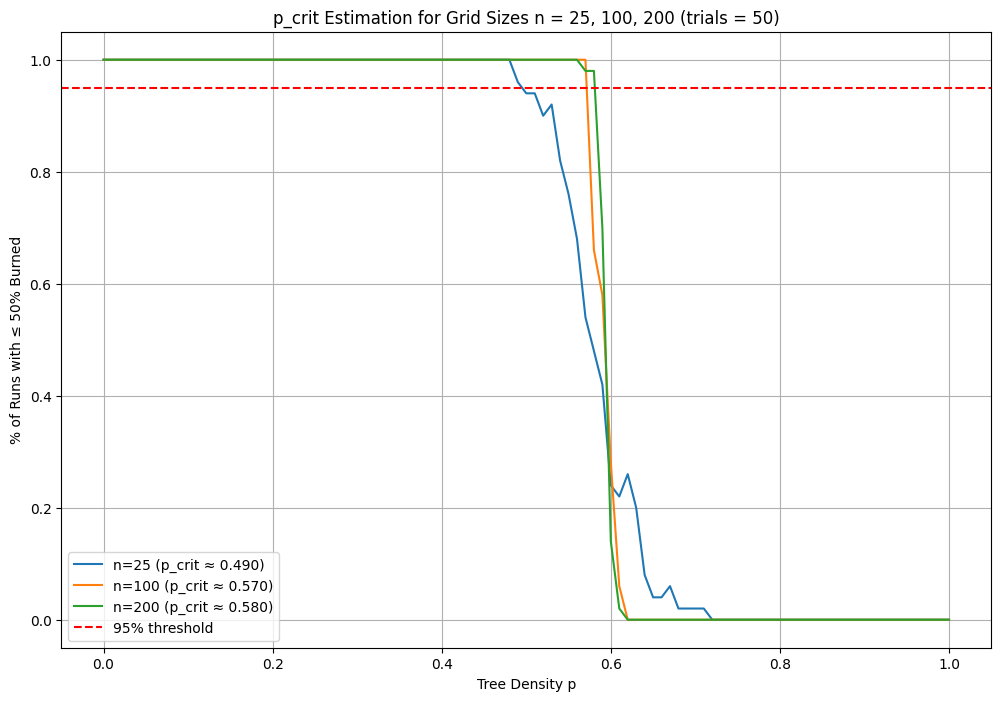


Estimated Critical Density (p_crit) for each grid size:

  Grid Size (n) |   Estimated p_crit
-------------------------------------
             25 | 0.490
            100 | 0.570
            200 | 0.580


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Base functions ---
def initialize_forest(n, p):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p, p])

def ignite_bottom_row(forest):
    for j in range(forest.shape[1]):
        if forest[-1, j] == 1:
            forest[-1, j] = 2  # burning

def spread_fire(forest):
    n = forest.shape[0]
    while True:
        burning = np.argwhere(forest == 2)
        if len(burning) == 0:
            break
        new_forest = forest.copy()
        for i, j in burning:
            new_forest[i, j] = 3
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n and forest[ni, nj] == 1:
                    new_forest[ni, nj] = 2
        forest = new_forest
    return forest

def run_single_simulation(n, p):
    forest = initialize_forest(n, p)
    ignite_bottom_row(forest)
    final = spread_fire(forest)
    total_trees = np.sum((final == 1) | (final == 2) | (final == 3))
    burned = np.sum(final == 3)
    burned_percent = (burned / total_trees) * 100 if total_trees > 0 else 0
    return burned_percent <= 50

def estimate_p_crit(n, trials=50, p_values=np.linspace(0, 1, 101)):
    results = []
    for p in p_values:
        success_count = sum(run_single_simulation(n, p) for _ in range(trials))
        rate = success_count / trials
        results.append((p, rate))
    p_crit_candidates = [p for p, r in results if r >= 0.95]
    p_crit = max(p_crit_candidates) if p_crit_candidates else None
    return results, p_crit

# --- Run and plot for each n ---
sizes = [25, 100, 200]
crit_table = {}

plt.figure(figsize=(12, 8))
for n in sizes:
    results, p_crit = estimate_p_crit(n=n, trials=50)
    p_vals, success_rates = zip(*results)
    plt.plot(p_vals, success_rates, label=f'n={n} (p_crit ≈ {p_crit:.3f})' if p_crit else f'n={n} (no p_crit)')
    crit_table[n] = p_crit

# Plot formatting
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Tree Density p')
plt.ylabel('% of Runs with ≤ 50% Burned')
plt.title('p_crit Estimation for Grid Sizes n = 25, 100, 200 (trials = 50)')
plt.grid(True)
plt.legend()
plt.show()

# --- Summary Table ---
print("\nEstimated Critical Density (p_crit) for each grid size:\n")
print(f"{'Grid Size (n)':>15} | {'Estimated p_crit':>18}")
print("-" * 37)
for n in sizes:
    pc = crit_table[n]
    print(f"{n:>15} | {pc:.3f}" if pc is not None else f"{n:>15} | Not Found")

The critical value pₙᶜʳⁱᵗ is not invariant — it clearly scales with the grid size n.

From your results:

For n = 25, p_crit ≈ 0.490

For n = 50, p_crit ≈ 0.550

For n = 100, p_crit ≈ 0.570

For n = 200, p_crit ≈ 0.580

We observe that as the grid size increases, the estimated critical density p_crit also increases slightly and becomes more stable. This suggests that larger grids provide a better approximation of the true critical threshold in the theoretical model.

Conclusion:
p_crit is not constant; instead, it gradually increases and converges as n grows. This behavior aligns with expectations from percolation theory, where finite-size effects become less significant in larger grids

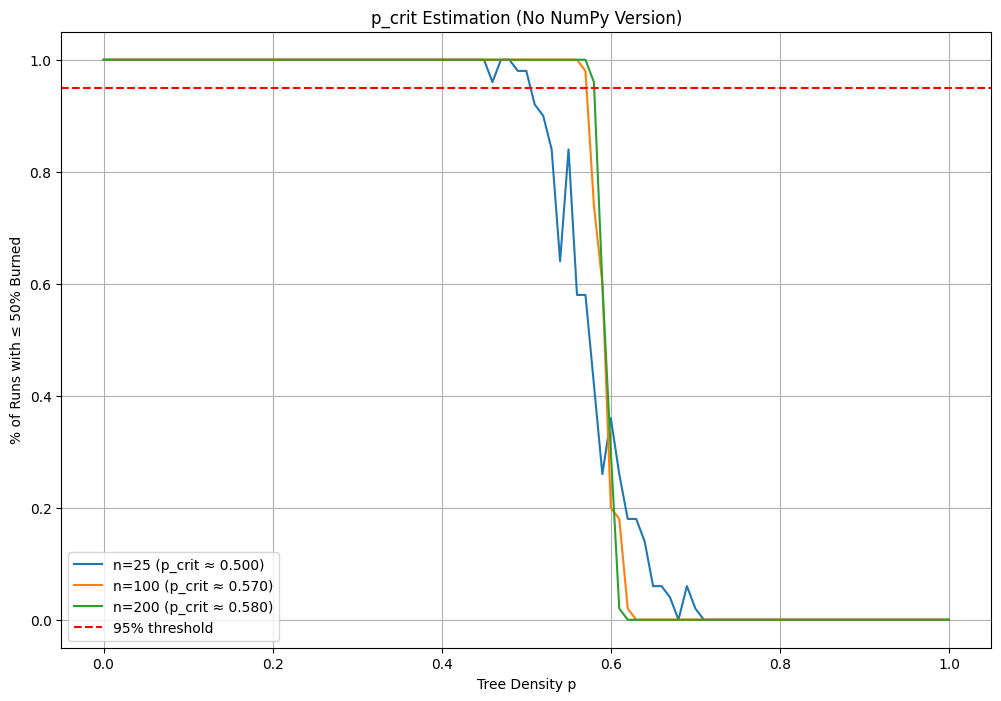


Estimated Critical Density (p_crit) for each grid size:

  Grid Size (n) |   Estimated p_crit
-------------------------------------
             25 | 0.500
            100 | 0.570
            200 | 0.580


In [ ]:
import random
import matplotlib.pyplot as plt

# --- Base functions without NumPy ---
def initialize_forest(n, p):
    return [[1 if random.random() < p else 0 for _ in range(n)] for _ in range(n)]

def ignite_bottom_row(forest):
    n = len(forest)
    for j in range(n):
        if forest[n - 1][j] == 1:
            forest[n - 1][j] = 2  # burning

def spread_fire(forest):
    n = len(forest)
    while True:
        burning_cells = [(i, j) for i in range(n) for j in range(n) if forest[i][j] == 2]
        if not burning_cells:
            break
        new_forest = [row.copy() for row in forest]
        for i, j in burning_cells:
            new_forest[i][j] = 3  # burned
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + dx, j + dy
                if 0 <= ni < n and 0 <= nj < n and forest[ni][nj] == 1:
                    new_forest[ni][nj] = 2
        forest = new_forest
    return forest

def run_single_simulation(n, p):
    forest = initialize_forest(n, p)
    ignite_bottom_row(forest)
    final = spread_fire(forest)
    total_trees = sum(cell in [1, 2, 3] for row in final for cell in row)
    burned = sum(cell == 3 for row in final for cell in row)
    burned_percent = (burned / total_trees) * 100 if total_trees > 0 else 0
    return burned_percent <= 50

def estimate_p_crit(n, trials=10, p_values=None):
    if p_values is None:
        p_values = [i / 100 for i in range(101)]  # 101 values from 0.00 to 1.00
    results = []
    for p in p_values:
        success_count = sum(run_single_simulation(n, p) for _ in range(trials))
        rate = success_count / trials
        results.append((p, rate))
    p_crit_candidates = [p for p, r in results if r >= 0.95]
    p_crit = max(p_crit_candidates) if p_crit_candidates else None
    return results, p_crit

# --- Run and plot for each n ---
sizes = [25,100,200]  # You can change these as needed
crit_table = {}

plt.figure(figsize=(12, 8))
for n in sizes:
    results, p_crit = estimate_p_crit(n=n, trials=50)  # Increase trials as needed
    p_vals, success_rates = zip(*results)
    label = f'n={n} (p_crit ≈ {p_crit:.3f})' if p_crit else f'n={n} (no p_crit)'
    plt.plot(p_vals, success_rates, label=label)
    crit_table[n] = p_crit

# Plot formatting
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Tree Density p')
plt.ylabel('% of Runs with ≤ 50% Burned')
plt.title('p_crit Estimation (No NumPy Version)')
plt.grid(True)
plt.legend()
plt.show()

# --- Summary Table ---
print("\nEstimated Critical Density (p_crit) for each grid size:\n")
print(f"{'Grid Size (n)':>15} | {'Estimated p_crit':>18}")
print("-" * 37)
for n in sizes:
    pc = crit_table[n]
    print(f"{n:>15} | {pc:.3f}" if pc is not None else f"{n:>15} | Not Found")